In [24]:
!pip install -q PyPortfolioOpt

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage

# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

In [2]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.443176,170.404495,41.931019,54.717323,76.912788,64.291069,540.298645,102.615845,341.583588,75.843269,...,154.084106,147.359787,392.184143,29.220690,453.210419,399.926666,230.069733,46.069378,45.858707,55.607391
2022-01-04,176.178406,167.522003,43.574490,55.142239,77.167366,67.079910,537.934204,104.482994,343.629395,79.329262,...,154.306808,147.875381,387.097229,30.639351,453.058563,383.196655,229.634109,47.903805,45.018570,57.699024
2022-01-05,171.492065,164.356995,42.839001,54.500546,77.485611,65.929520,524.291077,105.162727,340.098419,77.873306,...,154.832336,148.544830,375.205261,30.639351,444.358887,362.706665,224.653412,47.486065,45.627270,58.416637
2022-01-06,168.629318,163.253998,43.701603,56.286880,76.976433,68.404602,524.176697,106.057587,338.510376,79.470711,...,154.867996,147.296463,374.941620,31.367104,443.941498,354.899994,224.596603,48.702965,45.500454,59.790642
2022-01-07,168.795990,162.554001,44.654987,57.041302,76.776382,70.278343,511.191345,107.580559,338.435638,81.667145,...,155.063950,147.215027,370.879913,32.269886,442.186371,342.320007,223.573914,49.738220,45.934795,60.280720


# Setting Up Markowitz Portfolio Theory

First, let us set up Markowitz Portfolio Theory. Let $r$ be a matrix of T historical daily log returns of n stocks:

$$
r =
\begin{bmatrix}
r_{t-1,1} & \cdots & r_{t-1,n} \\
\vdots & \ddots & \vdots \\
r_{t-T,1} & \cdots & r_{t-T,n}
\end{bmatrix},
$$

where:  
- $T$ is the number of days, so $T=752$  
- $n$ is number of stocks, so $n=30
- $r_{t,n}$ is the historical log return for the $n$-th stock for day $t$

For our case, $r$ is 
Then $\hat{\mu}$ is a vector of means of annualized expected log return:

$$
\hat{\mu} =
\begin{bmatrix}
\hat{\mu}_1 \\
\vdots \\
\hat{\mu}_n
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,1} \\
\vdots \\
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,n}
\end{bmatrix},
$$

and $\hat{\Sigma}$ is the variance-covariance matrix of nnualized expected log return:

$$
\hat{\Sigma} =
\begin{bmatrix}
\hat{\sigma}_1^2 & \cdots & \hat{\sigma}_{1,n} \\
\vdots & \ddots & \vdots \\
\hat{\sigma}_{1,n} & \cdots & \hat{\sigma}_n^2
\end{bmatrix},
$$

where $\hat{\sigma}_i^2$ is the empirical variance of historical log returns of the $i$-th stock and $\hat{\sigma}_{i,j}$ is the empirical covariance between historical log returns of the $i$-th and $j$-th stock.  

  Stock   Weight
0   MPC  0.14690
1  NVDA  0.14750
2   WMT  0.56538
3   XOM  0.14021

Expected annual return: 25.3%
Annual volatility: 18.2%
Sharpe Ratio: 1.28


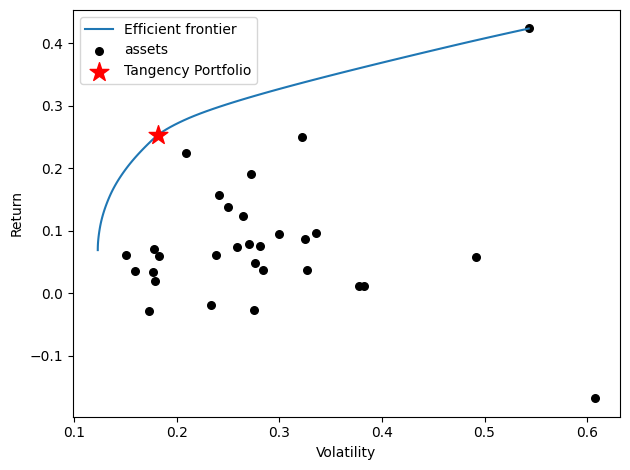

In [3]:
# mu and Sigma are annualized
mu = mean_historical_return(close_historical_df, log_returns=True)
Sigma = CovarianceShrinkage(close_historical_df, log_returns=True).ledoit_wolf()

# Compute tangency portfolio
ef_tan = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan.max_sharpe(risk_free_rate=0.02)
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in ef_tan.clean_weights().items() if weight > 0],
    columns=['Stock', 'Weight']
)
print(weights_df)
print()
exp_return, vol, sharpe = ef_tan.portfolio_performance(verbose=True, risk_free_rate=0.02)

# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=True)
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)
plt.legend()
plt.show()

In [4]:
# Define date range
start = "2025-01-01"
end = "2025-11-01"

# Download historical data
close_test_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]

[*********************100%***********************]  30 of 30 completed


In [5]:
from typing import Dict, List, Optional, Union

import numpy as np
import pandas as pd

from utils import TradingMetrics as trade_metrics


class Backtest:
    """Perform backtesting to assess the model's profitability on observed
    data.
    """

    def __init__(
        self, starting_capital: int = 10000, transaction_cost: float = 0.001
    ) -> None:
        self.starting_capital = starting_capital
        self.transaction_cost = transaction_cost
        self._reset()

    def _reset(self):
        """Reset to avoid errors for every run of the strategy."""
        self.cash = self.starting_capital
        self.position = 0
        self.portfolio_values = []
        self.trades = []
        self.trade_log = []

    def run_strategy(
        self,
        actual_prices: Union[np.ndarray, pd.Series],
        predicted_prices: Union[np.ndarray, pd.Series],
        default: bool = True,
        threshold: float = 0.01,
    ) -> Optional[List[Dict[str, float]]]:
        """Run the trading strategy.

        Parameters:
        -----------
        actual_prices (np.ndarray, pd.Series): Actual prices
        predicted_prices (np.ndarray, pd.Series): Predicted prices
        default (bool): Indicates if the default strategy would be done
            (default=True)
        threshold (float): Threshold for the price difference between the
            actual vs predicted prices (default=0.01 -> 1% difference).
        """
        self._reset()  # Fixed to avoid any issues with re-running the strategy

        # Convert pandas Series into an array
        actual_prices = self._check_input_instance(actual_prices)
        predicted_prices = self._check_input_instance(predicted_prices)

        if default:
            return self.default_strategy(
                actual_prices, predicted_prices, threshold=threshold
            )
        return self.custom_strategy(actual_prices, predicted_prices)

    def default_strategy(
        self,
        actual_prices: Union[np.ndarray, pd.Series],
        predicted_prices: Union[np.ndarray, pd.Series],
        threshold: float = 0.01,
    ):
        """Conduct a simple thresholding strategy. The rules are:
        - BUY: If predicted prices > actual prices * (1 + threshold) and no
            position
        - SELL: If predicted prices < actual prices * (1 - threshold) and holding
            a position
        - HOLD: Otherwise

        Parameters:
        -----------
        actual_prices (np.ndarray, pd.Series): Actual prices
        predicted_prices (np.ndarray, pd.Series): Predicted prices
        threshold (float): Acceptable threshold (in %) for actual vs predicted price
            difference. For example, if my model predicted a 1% higher price,
            we buy shares.
        """

        trade_length = len(actual_prices)

        for time in range(trade_length):
            action = "HOLD"
            shares_traded = 0

            current_price = actual_prices[time]
            predicted_price = predicted_prices[time]

            if predicted_price > current_price * (1 + threshold) and self.position == 0:
                # Buy as much shares as you can

                shares_to_buy = int(
                    self.cash / (current_price * (1 + self.transaction_cost))
                )

                if shares_to_buy > 0:
                    cost = shares_to_buy * current_price * (1 + self.transaction_cost)
                    self.cash -= cost
                    self.position = shares_to_buy
                    action = "BUY"
                    shares_traded = shares_to_buy
            elif (
                predicted_price < current_price * (1 - threshold) and self.position > 0
            ):
                # Sell everything
                revenue = self.position * current_price * (1 - self.transaction_cost)
                profit = revenue - (
                    self.position * self.entry_price * (1 + self.transaction_cost)
                )
                self.trades.append(profit)
                self.cash += revenue
                action = "SELL"
                shares_traded = self.position
                self.position = 0

            if action == "BUY":
                self.entry_price = current_price

            # Compute portfolio value
            portfolio_value = self.cash + (self.position * current_price)
            self.portfolio_values.append(portfolio_value)

            # Log your trade
            self.trade_log.append(
                {
                    "Actual Price": current_price,
                    "Predicted Price": predicted_price,
                    "Action": action,
                    "Shares Traded": shares_traded,
                    "Position": self.position,
                    "Cash": self.cash,
                    "Portfolio Value": portfolio_value,
                }
            )
        return self.trade_log

    # ================================START==================================
    # =================DELETE THESE COMMENTS AFTER EDITING===================
    # FEEL FREE TO EDIT THE METHOD BELOW TO INCLUDE YOUR OWN TRADING STRATEGY
    # ENSURE YOU INCLUDE DOCSTRINGS AND TYPE ANNOTATIONS
    def custom_strategy(self, actual_prices, predicted_prices):
        """
        Strategy:
        - Buy all shares on the first day
        - Hold throughout
        - Sell all on the last day
        """
        # Reset before running
        self._reset()
        actual_prices = self._check_input_instance(actual_prices)

        first_price = actual_prices[0]
        last_price = actual_prices[-1]

        # ---- BUY on first day ----
        self.position = int(self.cash / (first_price * (1 + self.transaction_cost)))
        cost = self.position * first_price * (1 + self.transaction_cost)
        self.cash -= cost
        self.entry_price = first_price

        # Log after buy
        portfolio_value = self.cash + self.position * first_price
        self.portfolio_values.append(portfolio_value)
        self.trade_log.append({
            "Actual Price": first_price,
            "Predicted Price": first_price,
            "Action": "BUY",
            "Shares Traded": self.position,
            "Position": self.position,
            "Cash": self.cash,
            "Portfolio Value": portfolio_value
        })
        
        # ---- HOLD until last day ----
        for price in actual_prices[1:-1]:
            portfolio_value = self.cash + self.position * price
            self.portfolio_values.append(portfolio_value)
            self.trade_log.append({
                "Actual Price": price,
                "Predicted Price": price,
                "Action": "HOLD",
                "Shares Traded": 0,
                "Position": self.position,
                "Cash": self.cash,
                "Portfolio Value": portfolio_value
            })

        # ---- SELL on last day ----
        shares_sold = self.position
        revenue = shares_sold * last_price * (1 - self.transaction_cost)
        profit = revenue - (shares_sold * self.entry_price * (1 + self.transaction_cost))
        self.trades.append(profit)
        self.cash += revenue
        self.position = 0

        portfolio_value = self.cash
        self.portfolio_values.append(portfolio_value)
        self.trade_log.append({
            "Actual Price": last_price,
            "Predicted Price": last_price,
            "Action": "SELL",
            "Shares Traded": shares_sold,  # <-- log actual sold shares
            "Position": self.position,
            "Cash": self.cash,
            "Portfolio Value": portfolio_value
        })


        return self.trade_log

    # ================================END===================================

    def compute_trade_metrics(self, annual_risk_free_rate: float = 0.02):
        """Return a dictionary of all trade metrics."""
        returns = self._get_returns()

        return trade_metrics.compute_all_metrics(
            self.portfolio_values, returns, self.trades, annual_risk_free_rate
        )

    def _get_returns(self):
        """Compute the portfolio returns."""
        if len(self.portfolio_values) < 2:
            return np.array([])
        portfolio = np.array(self.portfolio_values)
        return np.diff(portfolio) / portfolio[:-1]

    def _check_input_instance(self, input_arr: Union[np.ndarray, pd.Series]):
        if isinstance(input_arr, pd.Series):
            return np.asarray(input_arr)
        return input_arr


In [6]:
# from utils import PortfolioEvaluator
# from backtest import Backtest

markowitz_allocator = {stock:weight for stock, weight in ef_tan.clean_weights().items() if weight > 0}
markowitz_allocator['XOM'] = 0.14022
# 5. Initialize portfolio evaluator
portfolio = PortfolioEvaluator(allocation=markowitz_allocator)

# 6. Run backtests and add each stock to portfolio
for stock in markowitz_allocator.keys():
    alloc = markowitz_allocator[stock]
    starting_capital = portfolio.starting_capital * alloc

    bt = Backtest(starting_capital=starting_capital)
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=False)
    print(bt.trade_log[0])
    print(bt.trade_log[-1])
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Markowitz Model")

# 7. Inspect results
portfolio.show_report()

{'Actual Price': 139.11341857910156, 'Predicted Price': 139.11341857910156, 'Action': 'BUY', 'Shares Traded': 10, 'Position': 10, 'Cash': 76.47468002319351, 'Portfolio Value': 1467.6088658142091}
{'Actual Price': 194.91000366210938, 'Predicted Price': 194.91000366210938, 'Action': 'SELL', 'Shares Traded': 10, 'Position': 0, 'Cash': 2023.6256166076662, 'Portfolio Value': 2023.6256166076662}
{'Actual Price': 138.27987670898438, 'Predicted Price': 138.27987670898438, 'Action': 'BUY', 'Shares Traded': 10, 'Position': 10, 'Cash': 90.8184341430665, 'Portfolio Value': 1473.6172012329102}
{'Actual Price': 202.49000549316406, 'Predicted Price': 202.49000549316406, 'Action': 'SELL', 'Shares Traded': 10, 'Position': 0, 'Cash': 2113.6935890197756, 'Portfolio Value': 2113.6935890197756}
{'Actual Price': 89.32839965820312, 'Predicted Price': 89.32839965820312, 'Action': 'BUY', 'Shares Traded': 63, 'Position': 63, 'Cash': 20.48313235473688, 'Portfolio Value': 5648.172310821534}
{'Actual Price': 101.1

In [14]:
# from utils import PortfolioEvaluator
# from backtest import Backtest

markowitz_allocator = {stock:weight for stock, weight in ef_tan.clean_weights().items() if weight > 0}
markowitz_allocator['XOM'] = 0.14022
# 5. Initialize portfolio evaluator
portfolio = PortfolioEvaluator()

# 6. Run backtests and add each stock to portfolio
for stock in markowitz_allocator.keys():
    alloc = markowitz_allocator[stock]
    starting_capital = portfolio.starting_capital * alloc

    bt = Backtest(starting_capital=starting_capital)
    actual = close_test_df[stock].values

    #Run buy-and-hold custom strategy
    bt.run_strategy(actual_prices=actual, predicted_prices=actual, default=True)
    print(bt.trade_log[0])
    print(bt.trade_log[-1])
    portfolio.add_stock(stock_code=stock, backtester=bt, model_name="Markowitz Model")

# 7. Inspect results
portfolio.show_report()

{'Actual Price': 139.11341857910156, 'Predicted Price': 139.11341857910156, 'Action': 'HOLD', 'Shares Traded': 0, 'Position': 0, 'Cash': 1469.0, 'Portfolio Value': 1469.0}
{'Actual Price': 194.91000366210938, 'Predicted Price': 194.91000366210938, 'Action': 'HOLD', 'Shares Traded': 0, 'Position': 0, 'Cash': 1469.0, 'Portfolio Value': 1469.0}
{'Actual Price': 138.27987670898438, 'Predicted Price': 138.27987670898438, 'Action': 'HOLD', 'Shares Traded': 0, 'Position': 0, 'Cash': 1475.0, 'Portfolio Value': 1475.0}
{'Actual Price': 202.49000549316406, 'Predicted Price': 202.49000549316406, 'Action': 'HOLD', 'Shares Traded': 0, 'Position': 0, 'Cash': 1475.0, 'Portfolio Value': 1475.0}
{'Actual Price': 89.32839965820312, 'Predicted Price': 89.32839965820312, 'Action': 'HOLD', 'Shares Traded': 0, 'Position': 0, 'Cash': 5653.8, 'Portfolio Value': 5653.8}
{'Actual Price': 101.18000030517578, 'Predicted Price': 101.18000030517578, 'Action': 'HOLD', 'Shares Traded': 0, 'Position': 0, 'Cash': 5653.

In [12]:
portfolio.stocks['MPC']['backtester'].trade_log

[{'Actual Price': 139.11341857910156,
  'Predicted Price': 139.11341857910156,
  'Action': 'BUY',
  'Shares Traded': 10,
  'Position': 10,
  'Cash': 76.47468002319351,
  'Portfolio Value': 1467.6088658142091},
 {'Actual Price': 140.34242248535156,
  'Predicted Price': 140.34242248535156,
  'Action': 'HOLD',
  'Shares Traded': 0,
  'Position': 10,
  'Cash': 76.47468002319351,
  'Portfolio Value': 1479.8989048767091},
 {'Actual Price': 138.16952514648438,
  'Predicted Price': 138.16952514648438,
  'Action': 'HOLD',
  'Shares Traded': 0,
  'Position': 10,
  'Cash': 76.47468002319351,
  'Portfolio Value': 1458.1699314880373},
 {'Actual Price': 139.2805633544922,
  'Predicted Price': 139.2805633544922,
  'Action': 'HOLD',
  'Shares Traded': 0,
  'Position': 10,
  'Cash': 76.47468002319351,
  'Portfolio Value': 1469.2803135681154},
 {'Actual Price': 139.93931579589844,
  'Predicted Price': 139.93931579589844,
  'Action': 'HOLD',
  'Shares Traded': 0,
  'Position': 10,
  'Cash': 76.4746800231

In [10]:
close_test_df[markowitz_allocator.keys()]

Ticker,MPC,NVDA,WMT,XOM
Date,,,,
2025-01-02,139.113419,138.279877,89.328400,104.416374
2025-01-03,140.342422,144.438538,90.102592,104.951546
2025-01-06,138.169525,149.397446,90.747734,104.834785
2025-01-07,139.280563,140.109467,90.132362,105.817543
2025-01-08,139.939316,140.079483,91.114975,104.046623
...,...,...,...,...
2025-10-27,196.229996,191.490005,104.470001,115.940002
2025-10-28,192.210007,201.029999,103.169998,115.029999
2025-10-29,195.750000,207.039993,102.459999,116.449997


In [234]:
for stock, weight in markowitz_allocator.items():
    start_cap = portfolio.starting_capital * weight
    
    # Buy-and-hold: final value = starting_capital * (last_price / first_price)
    start_price = close_test_df[stock].iloc[0]
    end_price = close_test_df[stock].iloc[-1]
    
    final_value = start_cap * (end_price / start_price)
    returns = (end_price / start_price - 1)  # simple return
    
    print(f"{stock}: start ${start_cap:.2f}, final ${final_value:.2f}, return {returns:.2%}")


MPC: start $1469.00, final $2058.20, return 40.11%
NVDA: start $1475.00, final $2159.91, return 46.43%
WMT: start $5653.80, final $6403.92, return 13.27%
XOM: start $1402.20, final $1535.73, return 9.52%


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (4114143009.py, line 4)